# 04 — LightGBM Benchmark
ML model on the same features. Purpose is comparison and learning the interpretability trade-off.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path

PROC = Path('../Data/Processed')
OUT  = Path('../Outputs')

df = pd.read_parquet(PROC / 'master_features.parquet').sort_values('SK_ID_CURR')

with open(PROC / 'selected_features.json') as f:
    selected_features = json.load(f)

## 1. Train / OOT split

In [2]:
# .copy() prevents SettingWithCopyWarning when modifying column dtypes below
split = int(len(df) * 0.8)
train = df.iloc[:split].copy()
oot   = df.iloc[split:].copy()

print(f"Train: {len(train):,} rows | Default rate: {train['TARGET'].mean():.2%}")
print(f"OOT:   {len(oot):,} rows  | Default rate: {oot['TARGET'].mean():.2%}")

Train: 246,008 rows | Default rate: 8.11%
OOT:   61,503 rows  | Default rate: 7.94%


## 2. Train LightGBM

In [3]:
# convert string columns to categorical — LightGBM requires numeric or categorical dtype
cat_cols = [f for f in selected_features if df[f].dtype == 'object']
for col in cat_cols:
    train[col] = train[col].astype('category')
    oot[col]   = oot[col].astype('category')

dtrain = lgb.Dataset(train[selected_features], label=train['TARGET'])
dval   = lgb.Dataset(oot[selected_features],   label=oot['TARGET'], reference=dtrain)

params = {
    'objective':         'binary',
    'metric':            'auc',
    'learning_rate':     0.05,
    'num_leaves':        31,
    'min_child_samples': 200,
    'random_state':      42,
    'verbose':           -1,
}

model = lgb.train(
    params,
    dtrain,
    num_boost_round=300,
    valid_sets=[dval],
    callbacks=[lgb.early_stopping(30), lgb.log_evaluation(50)],
)

model.save_model(str(OUT / 'lgbm_model.txt'))
print(f"Best iteration: {model.best_iteration}")
print(f"Best OOT AUC:   {model.best_score['valid_0']['auc']:.4f}")

Training until validation scores don't improve for 30 rounds
[50]	valid_0's auc: 0.761736
[100]	valid_0's auc: 0.76906
[150]	valid_0's auc: 0.770898
[200]	valid_0's auc: 0.77164
[250]	valid_0's auc: 0.772426
[300]	valid_0's auc: 0.772375
Did not meet early stopping. Best iteration is:
[278]	valid_0's auc: 0.772534
Best iteration: 278
Best OOT AUC:   0.7725


## 3. SHAP explainability

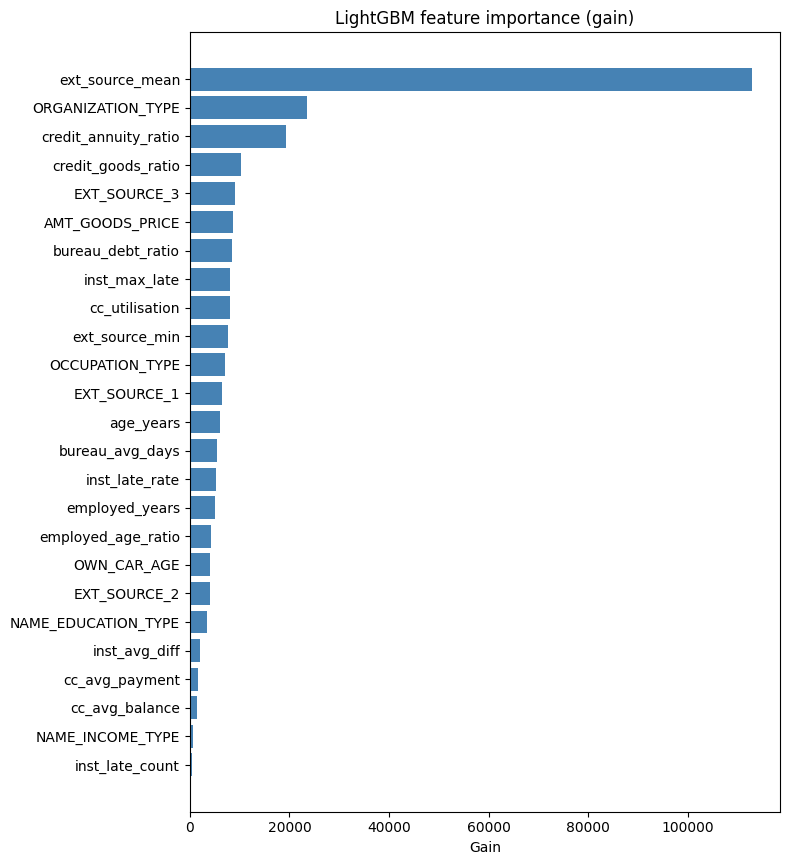

In [4]:
# feature importance by gain — how much each feature contributes to reducing loss
importance = pd.DataFrame({
    'feature':   model.feature_name(),
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(importance) * 0.35)))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_xlabel('Gain')
ax.set_title('LightGBM feature importance (gain)')
plt.tight_layout()
plt.savefig(OUT / 'lgbm_feature_importance.png', dpi=100)
plt.show()